Loading Data

In [61]:
import pandas as pd

In [62]:
inputdata = pd.read_csv("Eye_Health_Survey.csv")

new_columns = [
    'Age', 'Gender', 'Device', 'Screen_Time',
    'Continuous_Time', 'Distance', 'Lighting', 'Night_Mode',
    'Position', 'Parents_Glasses', 'Water', 'Blink_Aware',
    'Current_Glasses', 'Symptoms'
]
inputdata.columns = new_columns
inputdata.head()

,Age,Gender,Device,Screen_Time,Continuous_Time,Distance,Lighting,Night_Mode,Position,Parents_Glasses,Water,Blink_Aware,Current_Glasses,Symptoms
0,21,Male,Smartphone,10.0,30 to 60 mins,Arm's Length (Approx. 40-50 cm),Well-lit room (Natural or bright light),Sometimes,Below eye level (Looking slightly down - Ideal),No,More than 2 Liters,Yes,Yes,Sometimes
1,21,Male,Smartphone,12.0,More than 2 hours,Arm's Length (Approx. 40-50 cm),Dim light / Low light,"Yes, always",Below eye level (Looking slightly down - Ideal),"Yes, both parents",More than 2 Liters,Yes,Yes,Sometimes
2,28,Male,Smartphone,7.4,Less than 30 mins,Very Close (< 30 cm),Well-lit room (Natural or bright light),Sometimes,Below eye level (Looking slightly down - Ideal),"Yes, both parents",1 to 2 Liters,Yes,Yes,Rarely
3,21,Female,Smartphone,5.0,Less than 30 mins,Arm's Length (Approx. 40-50 cm),Well-lit room (Natural or bright light),"No, never",Below eye level (Looking slightly down - Ideal),No,1 to 2 Liters,No/ I don't pay attention,Yes,Rarely
4,42,Female,Smartphone,6.0,Less than 30 mins,Arm's Length (Approx. 40-50 cm),Well-lit room (Natural or bright light),"No, never",At eye level (Looking straight),"Yes, one parent",1 to 2 Liters,No/ I don't pay attention,No,Never


Label Encoding

In [63]:
labelencoding = {
    'Gender': {'Male': 0, 'Female': 1},

    'Device': {'Smartphone': 0, 'Laptop/Desktop': 1,'Tablet': 2},

    'Continuous_Time': {
        'Less than 30 mins': 0,
        '30 to 60 mins': 1,
        '1 to 2 hours': 2,
        'More than 2 hours': 3
    },

    'Distance': {
        'Very Close (< 30 cm)': 0,
        "Arm's Length (Approx. 40-50 cm)": 1,
        'Far (> 50 cm / Desktop distance)': 2
    },

    'Lighting': {
        'Well-lit room (Natural or bright light)': 0,
        'Dim light / Low light': 1,
        'Dark room (Lights off)': 2
    },

    'Night_Mode': {
        'Yes, always': 0,
        'Sometimes': 1,
        'No, never': 2
    },

    'Position': {
        'Below eye level (Looking slightly down - Ideal)': 0,
        'At eye level (Looking straight)': 1,
        'Above eye level (Looking up)': 2,
        'Lying down in bed (Variable)': 3
    },

    'Parents_Glasses': {
        'Yes, both parents': 0,
        'Yes, one parent': 1,
        'No': 2
    },

    'Water': {
        'Less than 1 Liter': 0,
        '1 to 2 Liters': 1,
        'More than 2 Liters': 2
    },

    'Blink_Aware': {
        'Yes': 0,
        "No/ I don't pay attention": 1
    },

    'Current_Glasses': {
        'No': 0,
        'Yes': 1
    },
    'Symptoms' : {
    'Never': 0,
    'Rarely': 0,
    'Sometimes': 1,
    'Frequently/Every Day': 1
    }
}

for col, mapping in labelencoding.items():
    inputdata[col] = inputdata[col].map(mapping)

Data Split

In [64]:
from sklearn.model_selection import train_test_split

In [65]:
features = ['Screen_Time', 'Distance', 'Continuous_Time', 'Lighting', 'Blink_Aware']
x = inputdata[features]
y = inputdata['Symptoms']

x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.8,random_state=42,stratify=y)

Model Creation

In [66]:
from sklearn.ensemble import RandomForestClassifier

In [67]:
rf_model = RandomForestClassifier(n_estimators=200, max_depth=4,random_state=42)
rf_model.fit(x_train, y_train)
y_pred = rf_model.predict(x_test)

Plotting

In [68]:
import matplotlib.pyplot as plt

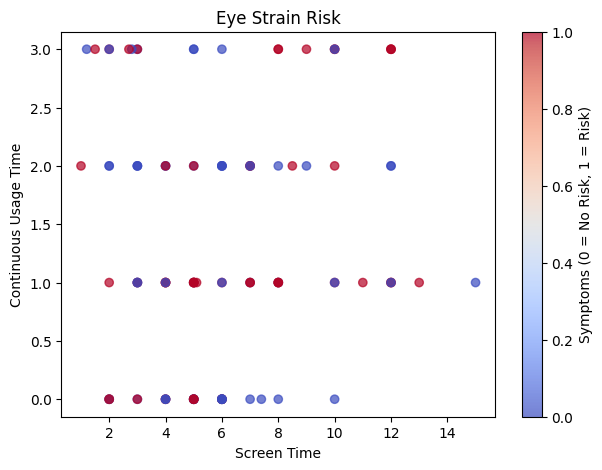

In [69]:
plt.figure(figsize=(7,5))

plt.scatter(inputdata['Screen_Time'],inputdata['Continuous_Time'],c=inputdata['Symptoms'],cmap='coolwarm',alpha=0.7)

plt.xlabel("Screen Time")
plt.ylabel("Continuous Usage Time")
plt.title("Eye Strain Risk")
plt.colorbar(label="Symptoms (0 = No Risk, 1 = Risk)")
plt.show()

Error Metric

In [70]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [71]:
acc = accuracy_score(y_test, y_pred)
print(f"Final Accuracy Score: {acc * 100 :.2f}%")
prec = precision_score(y_test, y_pred)
print(f"Final Precision Score: {prec * 100 :.2f}%")
recall = recall_score(y_test, y_pred)
print(f"Final Recall Score: {recall * 100 :.2f}%")
f1 = f1_score(y_test, y_pred)
print(f"Final F1 Score: {f1 * 100 :.2f}%")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Final Accuracy Score: 61.90%
Final Precision Score: 62.50%
Final Recall Score: 50.00%
Final F1 Score: 55.56%

Classification Report:

              precision    recall  f1-score   support

           0       0.62      0.73      0.67        11
           1       0.62      0.50      0.56        10

    accuracy                           0.62        21
   macro avg       0.62      0.61      0.61        21
weighted avg       0.62      0.62      0.61        21



Prediction on New Data

In [72]:
# 1. Screen_Time = 6 hours
# 2. Distance = 1  (Arm's Length)
# 3. Continuous_Time = 2 (1 to 2 hours)
# 4. Lighting = 1 (Dim light)
# 5. Blink_Aware = 1 (Not aware)

new_input = [[6, 1, 2, 1, 1]]

In [73]:
new_input_df = pd.DataFrame(new_input, columns=features)

In [74]:
prediction = rf_model.predict(new_input_df)
probability = rf_model.predict_proba(new_input_df)

In [75]:
if prediction[0] == 1:
    print("Eye Strain Risk Detected")
else:
    print("No Significant Eye Strain Risk")

print(f"Risk Probability: {probability[0][1]*100:.2f}%")

No Significant Eye Strain Risk
Risk Probability: 37.89%
